In [2]:
import pandas as pd
from kagglehub import KaggleDatasetAdapter
import kagglehub
import nltk
from nltk.tokenize import word_tokenize,sent_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tag import hmm
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,precision_score,recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from collections import Counter
from gensim.models import Word2Vec
import spacy
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import CountVectorizer

/Users/utsavlakshkar/Documents/GitHub/NLP_Assignment_1_Intelligent_Employee_Review_Feedback/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/utsavlakshkar/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/utsavlakshkar/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/utsavlakshkar/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/utsavlakshkar/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     /Users/utsavlakshkar/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Member 1 (Utsav Lakshkar): Data Collection, Preprocessing & Sentiment Classification

## Responsibilities

### Collect dataset (Kaggle Employee Reviews/Workplace Feedback)

### Data cleaning:

Remove special characters

Lowercasing

Stopword removal

Tokenization

Lemmatization/Stemming

### Create sentiment labels:

Positive

Negative

Neutral

### Build baseline sentiment classifier:

Naive Bayes / Logistic Regression / Random Forest

## Deliverables

Cleaned dataset

Data preprocessing pipeline

Sentiment classification model

Accuracy, Precision, Recall, F1-score

In [4]:

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "kunalpatil2181/employee-reviews",
    "employee_reviews.csv" 
)

print(df.head())
print(df.columns)
print(df.shape)

/var/folders/mw/g5fbh3hj76bg7bg2kvy7f_hm0000gn/T/ipykernel_13288/2989651872.py:1: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


   Unnamed: 0 company           location          dates  \
0           1  google               none   Dec 11, 2018   
1           2  google  Mountain View, CA   Jun 21, 2013   
2           3  google       New York, NY   May 10, 2014   
3           4  google  Mountain View, CA    Feb 8, 2015   
4           5  google    Los Angeles, CA   Jul 19, 2018   

                                  job-title  \
0     Current Employee - Anonymous Employee   
1         Former Employee - Program Manager   
2  Current Employee - Software Engineer III   
3     Current Employee - Anonymous Employee   
4       Former Employee - Software Engineer   

                                             summary  \
0                           Best Company to work for   
1  Moving at the speed of light, burn out is inev...   
2  Great balance between big-company security and...   
3  The best place I've worked and also the most d...   
4                    Unique, one of a kind dream job   

                         

In [5]:
print(df.head())

   Unnamed: 0 company           location          dates  \
0           1  google               none   Dec 11, 2018   
1           2  google  Mountain View, CA   Jun 21, 2013   
2           3  google       New York, NY   May 10, 2014   
3           4  google  Mountain View, CA    Feb 8, 2015   
4           5  google    Los Angeles, CA   Jul 19, 2018   

                                  job-title  \
0     Current Employee - Anonymous Employee   
1         Former Employee - Program Manager   
2  Current Employee - Software Engineer III   
3     Current Employee - Anonymous Employee   
4       Former Employee - Software Engineer   

                                             summary  \
0                           Best Company to work for   
1  Moving at the speed of light, burn out is inev...   
2  Great balance between big-company security and...   
3  The best place I've worked and also the most d...   
4                    Unique, one of a kind dream job   

                         

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 67529 entries, 0 to 67528
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Unnamed: 0                  67529 non-null  int64  
 1   company                     67529 non-null  str    
 2   location                    67529 non-null  str    
 3   dates                       67528 non-null  str    
 4   job-title                   67529 non-null  str    
 5   summary                     67402 non-null  str    
 6   pros                        67529 non-null  str    
 7   cons                        67529 non-null  str    
 8   advice-to-mgmt              66857 non-null  str    
 9   overall-ratings             67529 non-null  float64
 10  work-balance-stars          67529 non-null  str    
 11  culture-values-stars        67529 non-null  str    
 12  carrer-opportunities-stars  67529 non-null  str    
 13  comp-benefit-stars          67529 non-null

In [7]:
df['overall-ratings']=pd.to_numeric(df['overall-ratings'],errors='coerce').fillna(0).astype('int')
for i in df.columns:
    if i.endswith('stars'):
        df[i]=pd.to_numeric(df[i],errors='coerce').fillna(0).astype('int')
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 67529 entries, 0 to 67528
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Unnamed: 0                  67529 non-null  int64
 1   company                     67529 non-null  str  
 2   location                    67529 non-null  str  
 3   dates                       67528 non-null  str  
 4   job-title                   67529 non-null  str  
 5   summary                     67402 non-null  str  
 6   pros                        67529 non-null  str  
 7   cons                        67529 non-null  str  
 8   advice-to-mgmt              66857 non-null  str  
 9   overall-ratings             67529 non-null  int64
 10  work-balance-stars          67529 non-null  int64
 11  culture-values-stars        67529 non-null  int64
 12  carrer-opportunities-stars  67529 non-null  int64
 13  comp-benefit-stars          67529 non-null  int64
 14  senior-mangemnet-

In [8]:
df=df.drop(columns=['Unnamed: 0'])

In [9]:
df['summary']=df['summary'].fillna("")
df['advice-to-mgmt']=df['advice-to-mgmt'].fillna("")
df['dates']=df['dates'].fillna(pd.Timestamp.now().normalize())

In [10]:
def job_title_split(df):
    split_data = df['job-title'].astype(str).str.split("-", n=1, expand=True)
    
    # Grab the first word of the job section
    df['Employee Type'] = split_data[0].str.split().str[0]
    df['Designation'] = split_data[1]
    df.drop(columns=['job-title'],inplace=True)
    return df
    
df=job_title_split(df)
print(df.head())

  company           location          dates  \
0  google               none   Dec 11, 2018   
1  google  Mountain View, CA   Jun 21, 2013   
2  google       New York, NY   May 10, 2014   
3  google  Mountain View, CA    Feb 8, 2015   
4  google    Los Angeles, CA   Jul 19, 2018   

                                             summary  \
0                           Best Company to work for   
1  Moving at the speed of light, burn out is inev...   
2  Great balance between big-company security and...   
3  The best place I've worked and also the most d...   
4                    Unique, one of a kind dream job   

                                                pros  \
0                      People are smart and friendly   
1  1) Food, food, food. 15+ cafes on main campus ...   
2  * If you're a software engineer, you're among ...   
3  You can't find a more well-regarded company th...   
4  Google is a world of its own. At every other c...   

                                           

In [11]:
df.isnull().sum()

company                       0
location                      0
dates                         0
summary                       0
pros                          0
cons                          0
advice-to-mgmt                0
overall-ratings               0
work-balance-stars            0
culture-values-stars          0
carrer-opportunities-stars    0
comp-benefit-stars            0
senior-mangemnet-stars        0
helpful-count                 0
link                          0
Employee Type                 0
Designation                   0
dtype: int64

In [12]:
df.isna().sum()

company                       0
location                      0
dates                         0
summary                       0
pros                          0
cons                          0
advice-to-mgmt                0
overall-ratings               0
work-balance-stars            0
culture-values-stars          0
carrer-opportunities-stars    0
comp-benefit-stars            0
senior-mangemnet-stars        0
helpful-count                 0
link                          0
Employee Type                 0
Designation                   0
dtype: int64

In [13]:
def columns_pre_processing(df):
    tokenized=[]
    english_stop_words=set(stopwords.words("english"))
    wordnet_lemmatizer = WordNetLemmatizer()
    for text in df:
        if pd.notna(text) and text.strip():
            sentences = sent_tokenize(text)
        else:
            sentences=[]
        sentence_keywords=[]        
        for sentence in sentences:
            words = word_tokenize(sentence.lower())
            only_words = [w for w in words if w.isalpha()]            
            keywords=[w for w in only_words if not w in english_stop_words]            
            keywords = [wordnet_lemmatizer.lemmatize(w) for w in keywords]            
            sentence_keywords.extend(keywords)                        
        tokenized.append(sentence_keywords)
    return tokenized

def pre_processing(df):    
    for i in ['summary','pros','cons','advice-to-mgmt']:                
        df[i+'_tokenized']=columns_pre_processing(df[i])
    return df

df=pre_processing(df)  

In [14]:
def create_sentiment_label(rating):
    if rating >= 4:
        return "Positive"
    elif rating <= 2:
        return "Negative"
    else:
        return "Neutral"

df['sentiment'] = df['overall-ratings'].apply(create_sentiment_label)

print(df['sentiment'].value_counts())

sentiment
Positive    45688
Neutral     12653
Negative     9188
Name: count, dtype: int64


In [15]:
df['review_text'] = (
    df['summary'].fillna('') + " " +
    df['pros'].fillna('') + " " +
    df['cons'].fillna('') + " " +
    df['advice-to-mgmt'].fillna('')
)

In [16]:
df['summary_tokenized'] = columns_pre_processing(df['summary'])
df['pros_tokenized'] = columns_pre_processing(df['pros'])
df['cons_tokenized'] = columns_pre_processing(df['cons'])
df['advice-to-mgmt_tokenized'] = columns_pre_processing(df['advice-to-mgmt'])

In [17]:
df['processed_text'] = (
    df['summary_tokenized'].apply(lambda x: " ".join(x)) + " " +
    df['pros_tokenized'].apply(lambda x: " ".join(x)) + " " +
    df['cons_tokenized'].apply(lambda x: " ".join(x)) + " " +
    df['advice-to-mgmt_tokenized'].apply(lambda x: " ".join(x))
)

In [18]:
df['processed_text_tokenized'] = columns_pre_processing(df['processed_text'])

In [19]:
print(df.head())

  company           location          dates  \
0  google               none   Dec 11, 2018   
1  google  Mountain View, CA   Jun 21, 2013   
2  google       New York, NY   May 10, 2014   
3  google  Mountain View, CA    Feb 8, 2015   
4  google    Los Angeles, CA   Jul 19, 2018   

                                             summary  \
0                           Best Company to work for   
1  Moving at the speed of light, burn out is inev...   
2  Great balance between big-company security and...   
3  The best place I've worked and also the most d...   
4                    Unique, one of a kind dream job   

                                                pros  \
0                      People are smart and friendly   
1  1) Food, food, food. 15+ cafes on main campus ...   
2  * If you're a software engineer, you're among ...   
3  You can't find a more well-regarded company th...   
4  Google is a world of its own. At every other c...   

                                           

In [20]:
X = df['processed_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred,average='weighted'))
print("Recall:", recall_score(y_test, y_pred,average='weighted'))
print("F1 Score:", f1_score(y_test, y_pred,average='weighted'))

print(classification_report(y_test, y_pred))


Accuracy: 0.74418776839923
Precision: 0.7026771077279955
Recall: 0.74418776839923
F1 Score: 0.7081105860783858
              precision    recall  f1-score   support

    Negative       0.63      0.52      0.57      1837
     Neutral       0.44      0.19      0.26      2531
    Positive       0.79      0.94      0.86      9138

    accuracy                           0.74     13506
   macro avg       0.62      0.55      0.56     13506
weighted avg       0.70      0.74      0.71     13506



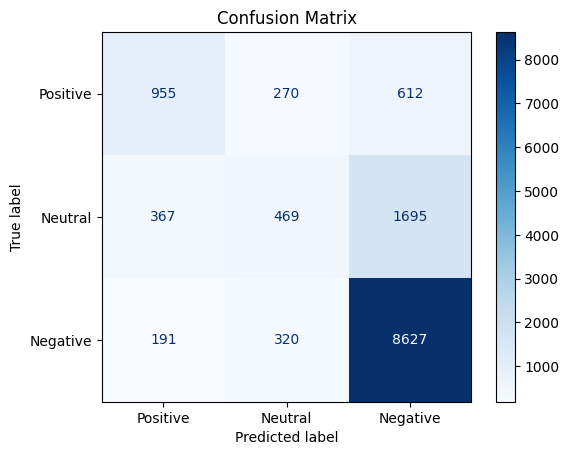

In [21]:
cm=confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pd.unique(df['sentiment']))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


# Member 2 (Aparna): Word Embeddings & Hidden Markov Model (HMM)

## Responsibilities

### Word Embeddings

* Generate word representations using Word2Vec / embedding techniques
* Analyze semantic similarity between workplace-related terms
* Visualize embedding relationships

### Hidden Markov Model (HMM)

* Implement HMM for sequence modeling
* Train HMM on sample workplace review sequences
* Analyze state transitions and observations

### Deliverables

* Word embedding model
* Similarity analysis results
* HMM implementation
* HMM output and observations

Word2Vec Embeddings

In [22]:
sentences = df['processed_text'].astype(str).apply(str.split).tolist()
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

print("Vocabulary Size:", len(w2v_model.wv))

if 'good' in w2v_model.wv:
    print("\nWords similar to 'good':")
    print(w2v_model.wv.most_similar('good', topn=5))
    print(w2v_model.wv.most_similar("management", topn=5))
    print(w2v_model.wv.most_similar("salary", topn=5))

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Vocabulary Size: 19507

Words similar to 'good':
[('great', 0.8187041878700256), ('excellent', 0.7957653999328613), ('decent', 0.7735336422920227), ('nice', 0.7307912111282349), ('awesome', 0.709884762763977)]
[('managment', 0.7240964770317078), ('mgmt', 0.6876063346862793), ('manager', 0.6561731696128845), ('leadership', 0.6288008093833923), ('manger', 0.5352411866188049)]
[('compensation', 0.8419527411460876), ('pay', 0.828328549861908), ('comp', 0.669090747833252), ('wage', 0.6495211720466614), ('payment', 0.6275926232337952)]



# Member 3 (Sudhakar K N): POS Tagging & Linguistic Analysis

## Responsibilities

### Part-of-Speech (POS) Tagging

* Tokenize employee reviews
* Apply POS tagging using NLTK
* Identify nouns, verbs, adjectives, and adverbs
* Analyze grammatical structure of workplace reviews

### Final Integration

* Integrate preprocessing, sentiment classification, word embeddings, HMM, and POS tagging modules
* Ensure smooth execution of the complete NLP pipeline
* Verify outputs from all modules
* Generate final results and visualizations

### Deliverables

* POS-tagged review samples
* POS tagging implementation
* Linguistic analysis report
* Integrated NLP workflow
* Final notebook execution
* Combined outputs and evaluation results

In [23]:
# POS Tagging on Dataset

all_pos_tags = []

for review in df['pros_tokenized'].dropna():

    if isinstance(review, list):

        tags = nltk.pos_tag(review)

        all_pos_tags.append(tags)

print("Total Reviews Processed:", len(all_pos_tags))

print("\nPOS Tags")
for i in range(10):
    print(all_pos_tags[i])

Total Reviews Processed: 67529

POS Tags
[('people', 'NNS'), ('smart', 'VBP'), ('friendly', 'JJ')]
[('food', 'NN'), ('food', 'NN'), ('food', 'NN'), ('cafe', 'NN'), ('main', 'JJ'), ('campus', 'NN'), ('mtv', 'NN'), ('alone', 'RB'), ('snack', 'JJ'), ('drink', 'VBP'), ('free', 'JJ'), ('day', 'NN'), ('free', 'JJ'), ('gym', 'NN'), ('access', 'NN'), ('mtv', 'NN'), ('campus', 'NN'), ('free', 'JJ'), ('self', 'NN'), ('service', 'NN'), ('laundry', 'RBR'), ('available', 'JJ'), ('bowling', 'NN'), ('alley', 'NN'), ('volley', 'NN'), ('ball', 'NN'), ('pit', 'NN'), ('exclusive', 'JJ'), ('employee', 'NN'), ('use', 'NN'), ('outdoor', 'JJ'), ('sport', 'NN'), ('park', 'NN'), ('mtv', 'VBD'), ('free', 'JJ'), ('assessment', 'NN'), ('etc', 'NN'), ('etc', 'FW'), ('etc', 'FW'), ('compensation', 'NN'), ('google', 'NN'), ('updated', 'JJ'), ('compensation', 'NN'), ('package', 'NN'), ('competitive', 'JJ'), ('size', 'NN'), ('organization', 'NN'), ('remained', 'VBD'), ('relatively', 'RB'), ('innovative', 'JJ'), ('nimb

Hidden Markov Model (HMM)

In [24]:
# HMM on Dataset

train_data = []

for review in df['processed_text_tokenized'].dropna().head(500):
    if isinstance(review, list):        
        train_data.append(nltk.pos_tag(review))        

trainer = hmm.HiddenMarkovModelTrainer()

model = trainer.train_supervised(train_data)

test_sentence = ['great', 'company', 'benefits']

print("HMM Prediction:")
print(model.tag(test_sentence))

HMM Prediction:
[('great', 'JJ'), ('company', 'NN'), ('benefits', 'JJS')]


/Users/utsavlakshkar/Documents/GitHub/NLP_Assignment_1_Intelligent_Employee_Review_Feedback/lib/python3.14/site-packages/nltk/tag/hmm.py:333: RuntimeWarning: overflow encountered in cast
  X[i, j] = self._transitions[si].logprob(self._states[j])
/Users/utsavlakshkar/Documents/GitHub/NLP_Assignment_1_Intelligent_Employee_Review_Feedback/lib/python3.14/site-packages/nltk/tag/hmm.py:335: RuntimeWarning: overflow encountered in cast
  O[i, k] = self._output_logprob(si, self._symbols[k])
/Users/utsavlakshkar/Documents/GitHub/NLP_Assignment_1_Intelligent_Employee_Review_Feedback/lib/python3.14/site-packages/nltk/tag/hmm.py:331: RuntimeWarning: overflow encountered in cast
  P[i] = self._priors.logprob(si)
/Users/utsavlakshkar/Documents/GitHub/NLP_Assignment_1_Intelligent_Employee_Review_Feedback/lib/python3.14/site-packages/nltk/tag/hmm.py:363: RuntimeWarning: overflow encountered in cast
  O[i, k] = self._output_logprob(si, self._symbols[k])



# Member 4 (Akesh John): Final Integration, Evaluation & Documentation

## Responsibilities

### Model Evaluation
* Evaluate sentiment classification performance
* Calculate Accuracy, Precision, Recall, and F1-Score
* Generate Confusion Matrix
* Analyze model performance and results
### Documentation
* Document project methodology and workflow
* Summarize preprocessing, classification, HMM, POS tagging, and word embedding modules
* Record observations and findings
* Prepare conclusion and future scope
### Deliverables
* Evaluation metrics report
* Confusion Matrix and performance analysis
* Project documentation
* Conclusion and future scope section
* Final report compilation

Parsing

In [25]:
nlp = spacy.load("en_core_web_sm")

sample_text = " ".join(df['processed_text_tokenized'].iloc[0])

doc = nlp(sample_text)

print("Dependency Parsing Results:\n")

for token in doc[:20]:
    print(
        token.text,
        " --> ",
        token.dep_,
        " --> ",
        token.head.text
    )

Dependency Parsing Results:

best  -->  amod  -->  company
company  -->  compound  -->  work
work  -->  compound  -->  people
people  -->  ROOT  -->  people
smart  -->  amod  -->  thing
friendly  -->  amod  -->  bureaucracy
bureaucracy  -->  npadvmod  -->  slowing
slowing  -->  amod  -->  thing
thing  -->  appos  -->  people
none  -->  appos  -->  people


In [26]:
# Named Entity Recognition on Dataset

entity_results = []

for review in df['processed_text'].dropna().head(500):

    doc = nlp(str(review))

    for ent in doc.ents:

        entity_results.append((ent.text, ent.label_))

print("Total Entities Found:", len(entity_results))

print("\nSample Entities:")
print(entity_results[:20])

Total Entities Found: 229

Sample Entities:
[('mtv', 'ORG'), ('mtv', 'ORG'), ('volley ball', 'PERSON'), ('google', 'ORG'), ('midnight', 'TIME'), ('one year ago', 'DATE'), ('king hill google', 'ORG'), ('overnight', 'TIME'), ('vermont overnight', 'FAC'), ('summer summer', 'DATE'), ('google', 'PRODUCT'), ('every week', 'DATE'), ('larry', 'PERSON'), ('hour', 'TIME'), ('year', 'DATE'), ('roughly hour', 'TIME'), ('hour week', 'DATE'), ('couple year ago', 'DATE'), ('larry', 'PERSON'), ('google', 'ORG')]


In [27]:
doc = nlp("Google provides excellent career opportunities in Bangalore.")

for ent in doc.ents:
    print(ent.text, ent.label_)

Google ORG
Bangalore PERSON


Neural Language Model

In [28]:
corpus = df['processed_text'].dropna().astype(str).head(500)

tokens = " ".join(corpus).split()

print("Vocabulary Size:", len(set(tokens)))
print("Total Tokens:", len(tokens))

X_words = tokens[:-1]
y_words = tokens[1:]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(X_words)

mlp_lm = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=20,
    random_state=42
)

mlp_lm.fit(X, y_words)

Vocabulary Size: 2738
Total Tokens: 13434


/Users/utsavlakshkar/Documents/GitHub/NLP_Assignment_1_Intelligent_Employee_Review_Feedback/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (20) reached and the optimization hasn't converged yet.
  warnings.warn(


,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",20
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [29]:
all_tokens = []

for review in df['pros_tokenized'].dropna():

    if isinstance(review, list):
        all_tokens.extend(review)

bigrams = list(nltk.bigrams(all_tokens))

print("Total Tokens:", len(all_tokens))
print("Total Bigrams:", len(bigrams))

bigram_freq = Counter(bigrams)

print("\nTop 20 Most Common Bigrams:")
print(bigram_freq.most_common(20))

Total Tokens: 840219
Total Bigrams: 840218

Top 20 Most Common Bigrams:
[(('great', 'benefit'), 3976), (('smart', 'people'), 3732), (('place', 'work'), 2598), (('good', 'benefit'), 2411), (('work', 'environment'), 2307), (('work', 'life'), 2073), (('great', 'people'), 2038), (('life', 'balance'), 1998), (('people', 'work'), 1905), (('good', 'pay'), 1888), (('great', 'place'), 1723), (('benefit', 'great'), 1562), (('good', 'work'), 1539), (('great', 'company'), 1526), (('people', 'great'), 1356), (('work', 'great'), 1335), (('company', 'work'), 1312), (('great', 'work'), 1297), (('work', 'culture'), 1290), (('benefit', 'good'), 1282)]


Workplace Issue Classification

In [30]:
# Workplace Issue Classification

def classify_issue(text):

    text = str(text).lower()

    if any(word in text for word in
           ['salary', 'pay', 'benefit', 'compensation', 'bonus']):
        return "Salary & Benefits"

    elif any(word in text for word in
             ['career', 'promotion', 'growth', 'learning', 'training']):
        return "Career Growth"

    elif any(word in text for word in
             ['manager', 'management', 'boss', 'leadership', 'supervisor']):
        return "Management Issues"

    elif any(word in text for word in
             ['culture', 'team', 'people', 'environment', 'workplace']):
        return "Work Culture"

    else:
        return "Other"


df['issue_category'] = df['processed_text'].apply(classify_issue)

print("Issue Category Distribution:\n")
print(df['issue_category'].value_counts())

print("\nSample Classification:\n")
sample_output = df[
    ['review_text', 'sentiment', 'issue_category']
].head(10)

print(sample_output)

Issue Category Distribution:

issue_category
Salary & Benefits    30904
Work Culture         10483
Career Growth         8947
Other                 8760
Management Issues     8435
Name: count, dtype: int64

Sample Classification:

                                         review_text sentiment  \
0  Best Company to work for People are smart and ...  Positive   
1  Moving at the speed of light, burn out is inev...  Positive   
2  Great balance between big-company security and...  Positive   
3  The best place I've worked and also the most d...  Positive   
4  Unique, one of a kind dream job Google is a wo...  Positive   
5  NICE working in GOOGLE as an INTERN People are...  Positive   
6  Software engineer Great working environment. G...  Positive   
7  great place to work and progress work culture,...  Positive   
8  Google Surpasses Realistic Expectations Great ...  Positive   
9  Execellent for engineers Impact driven. Best t...  Positive   

      issue_category  
0       Work Cultur

# Final Output Section

In [31]:
print("===== NLP ASSIGNMENT SUMMARY =====")

print("\nDataset Size:", len(df))

print("\nPOS Tagged Reviews:", len(all_pos_tags))

print("\nTotal Tokens:", len(all_tokens))

print("\nTotal Bigrams:", len(bigrams))

print("\nTop 10 Bigrams:")
for item in bigram_freq.most_common(10):
    print(item)

print("\nNER Entities Found:", len(entity_results))

print("\nIssue Categories:")
print(df['issue_category'].value_counts())

===== NLP ASSIGNMENT SUMMARY =====

Dataset Size: 67529

POS Tagged Reviews: 67529

Total Tokens: 840219

Total Bigrams: 840218

Top 10 Bigrams:
(('great', 'benefit'), 3976)
(('smart', 'people'), 3732)
(('place', 'work'), 2598)
(('good', 'benefit'), 2411)
(('work', 'environment'), 2307)
(('work', 'life'), 2073)
(('great', 'people'), 2038)
(('life', 'balance'), 1998)
(('people', 'work'), 1905)
(('good', 'pay'), 1888)

NER Entities Found: 229

Issue Categories:
issue_category
Salary & Benefits    30904
Work Culture         10483
Career Growth         8947
Other                 8760
Management Issues     8435
Name: count, dtype: int64
